# <h1><center> **Universidad Nacional Autonoma de México.** </center></h1>
# <h3><center> **Facultad de Estudios Superiores Acatlán.** </center></h3>
# <h4><center> **Tecnicas Estadisticas y Mineria de Datos** </center></h4>
# <h3><center>*Modulo IV*</center></h3>
---

# <center> *Practica: Datos en Crudo* </center>

---
**Profesor:** JAVIER ROSAS HERNÁNDEZ \\

***Grupo - 35***                $~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$
***11 de Junio del 2025***

Apartir del archivo: *\"Datos.csv\"* Realiza los siguientes pasos:

1. Analizar los datos y obtener las estadísticas descriptivas (al menos 4 medidas).

2. Seleccionar y justificar las 4 variables más representativas.

3. Visualizar datos: sugerir gráficos más representativos (al menos 4).

4. Determinar si existen y cuántos valores faltantes hay por cada atributo.

5. Determina si eliminar los registros inconsistentes es representativo de la población. Justificar.

6. Ejemplificar un proceso de transformación para valores faltantes o datos inconsistentes (“raros”).

7. Obtener la matriz de correlación de hasta 8 variables. Interpretar el resultado.

**Solucion:**

Antes de comenzar hay que establecer algunas paqueterias necesarios para realizar cada uno de los incisos y de paso el exporta la informacion para su previa manipulacion.

In [46]:
import numpy as np      # Manipulacion de estructuras matematicas
import pandas as pd     # Manipulacion de base de datos en tablas
import seaborn as sns   # Creacion de graficas estadisticas
import matplotlib.pyplot as plt   # Creacion de las graficas descriptivas en general.

In [47]:
#=============== importamos los datos ===============#

tabla = pd.read_csv('Datos.csv', header = 0)
tabla

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,...,O8,O9,O10,A,B,C,D,E,F,G
0,4,2,5,2,5,1,4,3,5,1,...,2,5,5,3,53.0,1.0,1,1,1,US
1,2,2,3,3,3,3,1,5,1,5,...,1,3,2,13,46.0,1.0,2,1,1,US
2,5,1,1,4,5,1,1,5,5,1,...,5,5,5,1,14.0,2.0,2,1,1,PK
3,2,5,2,4,3,4,3,4,4,5,...,2,5,5,3,19.0,2.0,2,1,1,RO
4,3,1,3,3,3,1,3,1,3,5,...,1,5,3,11,25.0,2.0,2,1,2,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19718,2,3,1,5,3,3,3,2,2,4,...,5,5,5,3,35.0,1.0,1,1,1,US
19719,4,1,4,2,5,1,5,1,5,1,...,2,4,5,3,16.0,1.0,2,1,1,MX
19720,5,3,4,2,3,2,5,3,4,2,...,3,5,3,3,18.0,1.0,1,1,5,US
19721,1,5,2,4,2,2,2,4,2,5,...,4,3,4,13,22.0,2.0,1,1,1,CO


# **Parte #1**

## **Analisis de los Datos**

Podemos observa en la visualizacion de la tabla anterior que es bastantemente grande de lo que esperabamos, tenemos:

* 19723 registros
* 57 columnas

de informacion organizada. Veamos como es la estructura de la tabla y el tipo de datos que maneja.

In [48]:
tabla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19723 entries, 0 to 19722
Data columns (total 57 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   E1      19723 non-null  int64  
 1   E2      19723 non-null  int64  
 2   E3      19723 non-null  int64  
 3   E4      19723 non-null  int64  
 4   E5      19723 non-null  int64  
 5   E6      19723 non-null  int64  
 6   E7      19723 non-null  int64  
 7   E8      19723 non-null  int64  
 8   E9      19723 non-null  int64  
 9   E10     19723 non-null  int64  
 10  N1      19723 non-null  int64  
 11  N2      19723 non-null  int64  
 12  N3      19723 non-null  int64  
 13  N4      19723 non-null  int64  
 14  N5      19723 non-null  int64  
 15  N6      19723 non-null  int64  
 16  N7      19723 non-null  int64  
 17  N8      19723 non-null  int64  
 18  N9      19723 non-null  int64  
 19  N10     19723 non-null  int64  
 20  A1      19723 non-null  int64  
 21  A2      19723 non-null  int64  
 22

Aunque a primera vista podemos observar que todos los datos estan regidos numericamente; hay algunas detalles a tener en cuentas mas adelante:

* Existe alguna **\" agrupacion de columnas de 10 elementos \"** y esto son identificados por la letra que componen su nombre y lo podemos ver por el siguiente codigo....

In [49]:
Columnas_Tablas = tabla.columns     # Almacenamos la lista de objetos

In [50]:
i = 0
while i <= 4:
  print(Columnas_Tablas[0+(i*10):9+(i*10)])
  i += 1

Index(['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9'], dtype='object')
Index(['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9'], dtype='object')
Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9'], dtype='object')
Index(['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9'], dtype='object')
Index(['O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9'], dtype='object')


A mi punto de vista; puedo ver que se trata de una serie de 10 aspectos que describen minusiosamente alguna caracteristica en particular *(5 de ellas presisamente)* y el resto de las columnas que son:

In [51]:
print(Columnas_Tablas[50:])     # imprimimos el resto de las columnas

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype='object')


Sean datos mas cuantitativos del evento a analizar.

* Apesar de que la mayoria de los datos son numericos; hay cosas que tenemos que contemplar:

  * Tanto las columnas: **B**, **C** son el tipo flotante.
  * La columna: **G** es la unica que tiene valores del tipo caracter *(por eso el indicativo de objeto)*.
  * El resto de las columnas contiene datos del tipo entero.

Estos tipos de datos son asi ya que estan indicando **el tipo de de V.A.** es. Esta entre valores *Continuos* y *Discretos*....

Para ello vamos a ver el rango de datos que tiene cada una de las columnas *(tanbien conocidas como V.A.)*.
  

In [52]:
# Para el caso de las columnas que son semejantes

for i in range(len(tabla.columns)):
  if i in [50,51,52,56]:
    continue
  else:
    print(f"La columna {tabla.columns[i]} tiene estos valores: {tabla.iloc[:, i].unique()}")

La columna E1 tiene estos valores: [4 2 5 3 1 0]
La columna E2 tiene estos valores: [2 1 5 3 4 0]
La columna E3 tiene estos valores: [5 3 1 2 4 0]
La columna E4 tiene estos valores: [2 3 4 1 0 5]
La columna E5 tiene estos valores: [5 3 1 2 4 0]
La columna E6 tiene estos valores: [1 3 4 2 5 0]
La columna E7 tiene estos valores: [4 1 3 2 5 0]
La columna E8 tiene estos valores: [3 5 4 1 2 0]
La columna E9 tiene estos valores: [5 1 4 3 2 0]
La columna E10 tiene estos valores: [ 1  5  3  4  2 10  0]
La columna N1 tiene estos valores: [1 2 5 3 4 0]
La columna N2 tiene estos valores: [5 3 1 4 2 0]
La columna N3 tiene estos valores: [2 4 5 3 1 0]
La columna N4 tiene estos valores: [5 2 4 3 1 0]
La columna N5 tiene estos valores: [1 3 5 4 2 0]
La columna N6 tiene estos valores: [1 4 5 3 2 0]
La columna N7 tiene estos valores: [1 3 5 4 2 0]
La columna N8 tiene estos valores: [1 2 5 3 4 0]
La columna N9 tiene estos valores: [1 2 5 4 3 0]
La columna N10 tiene estos valores: [ 1  4  5  2  3 10  0]


Podemos ver que la mayoria de los rangos en cada V.A. son del tipo discreto, entre $[0,5]$ y curiosamente sus datos son del tipo entero.

Mientras que las V.A. que tiene datos del tipo flotante y objetos son muy distintos....

In [53]:
# resto de las columnas

Val = [50, 51, 52, 56]
for i in Val:
    print(f"La columna {tabla.columns[i]} tiene estos valores: {tabla.iloc[:, i].unique()}")

La columna A tiene estos valores: [   3   13    1   11    5    4    8    6    9    0   10    7   12    2
 3000]
La columna B tiene estos valores: [5.30000000e+01 4.60000000e+01 1.40000000e+01 1.90000000e+01
 2.50000000e+01 3.10000000e+01 2.00000000e+01 2.30000000e+01
 3.90000000e+01 1.80000000e+01 1.70000000e+01 1.50000000e+01
 2.20000000e+01 2.10000000e+01 2.80000000e+01 2.60000000e+01
 2.90000000e+01 5.20000000e+01 4.80000000e+01 3.70000000e+01
 4.20000000e+01 2.70000000e+01 6.00000000e+01 2.40000000e+01
 4.70000000e+01 3.50000000e+01 3.40000000e+01 3.60000000e+01
 5.40000000e+01 4.50000000e+01 3.20000000e+01 4.90000000e+01
 1.30000000e+01 3.30000000e+01 1.60000000e+01 3.00000000e+01
 5.90000000e+01 4.10000000e+01 4.40000000e+01 4.30000000e+01
 3.80000000e+01 1.99700000e+03 4.00000000e+01 5.50000000e+01
 5.80000000e+01 5.10000000e+01 5.70000000e+01 1.99500000e+03
 5.60000000e+01 6.80000000e+01 7.00000000e+01 5.00000000e+01
 7.60000000e+01 6.30000000e+01 6.50000000e+01 1.99400000e+03


Podemos decir que:

* Las columnas **C**, **A** son discretos muy distintos a la mayoria.

* La columna **B** es la unica que tiene un comportamiento Continuo en sus valores.

* La columna **G** es la unica que tiene un comportamiento de categorico en su valores para cada registros.

## **Estadistica Descriptiva**

Pasando a ver algunas metrica que nos ayude a ver como es el comportamiento de las V.A.s en base a la informacion que tenemos a nuestra disposicion, veremos las parametros mas clasicos en estos analisis...

$\color{green}{\text{Moda}}$

Recordemos que la moda es un termino que nos indica *\" el valor mas presente \"* de un V.A.

In [54]:
# Creamos una nueva tabla que almacena la moda de cada columna
Moda = tabla.mode()

# Invertimos el dataframe para mejor visualizacion
Moda.T

,0
E1,3
E2,2
E3,4
E4,3
E5,4
E6,2
E7,1
E8,4
E9,4
E10,5


Si vemos cual es **la moda de la moda** de la tabla que es por si el $4$.

In [55]:
Moda.T.mode()

,0
0,4


$\color{green}{\text{Media}}$

La media *(conocida mas como promedio)* es un termino que nos indica *\" el valor mas representativo \"* de la V.A. El unico detalle es que aplica para valores numericos...

In [56]:
# Creamos una nueva tabla que almacena la media de cada columna
Promedio = tabla.drop('G', axis = 1).mean()

# Invertimos el dataframe para mejor visualizacion
Promedio.T

,0
E1,2.629012
E2,2.759671
E3,3.416772
E4,3.151498
E5,3.432287
E6,2.452467
E7,2.867566
E8,3.376312
E9,3.094306
E10,3.585560


En el caso de la Columna **B** podemos ver que hay una gran variancion de sus media con respecto a las demas, presencia de datos inconsistentes *(atipicos)*

$\color{green}{\text{Medidas de dispercion y Mediana}}$

Esto terminos en estadistica son conocidas como **Percentil** que consiste en dividir el conjunto de datos ordenados partes y ver que datos se encuentra en dicha divisiones.

En este caso vamos a verlo en 4 partes *(llamado Cuartiles)* y curiosamente **la mediana** sera el valor central de dichos datos; ya que que esta indicando el $50\%$ del tamano de los datos

El unico detalle es que aplica para valores numericos...

In [57]:
# Calculo los cuartiles
ajustes = tabla.drop('G', axis = 1).quantile([0.25, 0.5, 0.75])

# Invertimos nuestra tabla
Cuatiles = ajustes.T

# Cambiamos los titulos de nuestra tabla
Cuatiles.columns = ['Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)']

# Mostramos la tabla
Cuatiles

,Q1 (25%),Mediana (50%),Q3 (75%)
E1,2.0,3.0,4.0
E2,2.0,3.0,4.0
E3,3.0,4.0,4.0
E4,2.0,3.0,4.0
E5,2.0,4.0,5.0
E6,1.0,2.0,3.0
E7,2.0,3.0,4.0
E8,2.0,3.0,4.0
E9,2.0,3.0,4.0
E10,3.0,4.0,5.0


$\color{green}{\text{Desviacion Estandar}}$

Este termino estadistico nos explica *\" el promedio en como se distribuyen los datos en su propio conjunto  \"*. El unico detalle es que aplica para valores numericos...

In [58]:
# Calculo los cuartiles
holis = tabla.drop('G', axis = 1).std()

# Invertimos nuestra tabla para mejor visualizacion
Disper = pd.DataFrame(holis.T)
Disper.columns = ['Desviacion Estandar']

# Mostramos la tabla
Disper

,Desviacion Estandar
E1,1.232781e+00
E2,1.313902e+00
E3,1.236757e+00
E4,1.223012e+00
E5,1.282015e+00
E6,1.241627e+00
E7,1.431923e+00
E8,1.266430e+00
E9,1.396691e+00
E10,1.305414e+00


# **Parte #2**

Ya con el analisis previo de los datos; podemos seleccionar las **V.A.** que para mi punto de vista son los mas representativos de los datos....

*   La columna: **G** ya que es una columna de que contiene una variedad de datos que clasifica nuestro registros.

*   Las columnas siguiente: **E10**, **N10**, **C8**, **O9** y **A7** ya que son las V.A.s que recaba mas informacion de los registros y por el hecho de establecerlos como los aspectos mas importantes de cada grupo que habiamos mencionado *(con excepcion del grupo de columnas A)*.

*   La columna: **B** por el simple hecho de que la V.A. es del tipo Continuo.

# **Parte #3**

Un ejemplo de grafica visual que nos pueda dar mas aportacion de informacion sobre el comportamiento de los datos seria por **grafica de barras**...

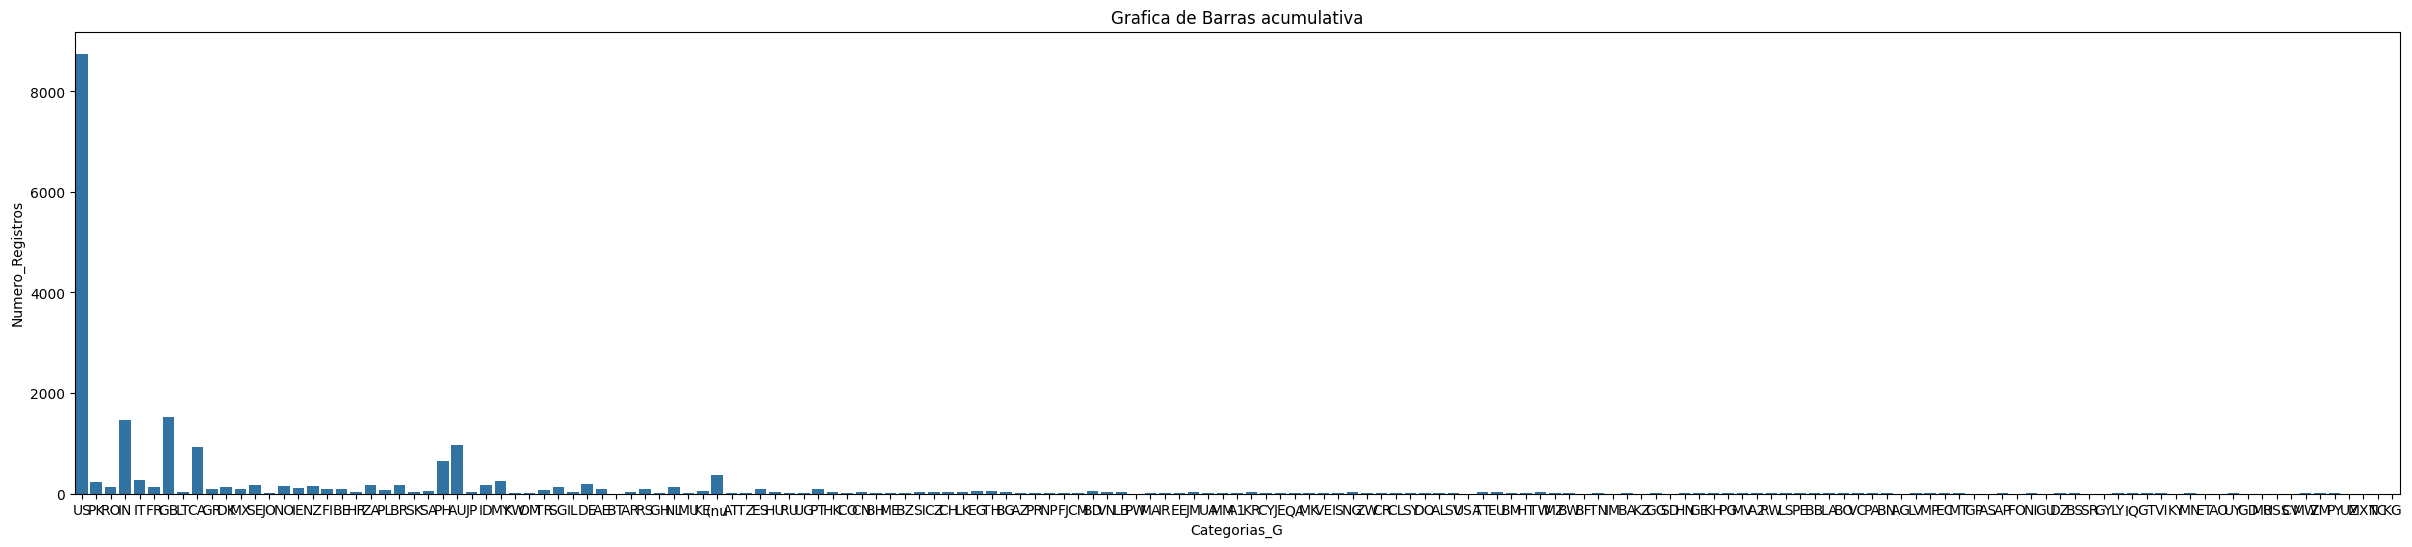

In [59]:
# Crear un lienzo con un tamano
plt.figure(figsize=(30, 6))

# Configuracion de la grafica de Barras que cuenta el numero de registros
sns.countplot(data = tabla, x = 'G')

# Configuramos los elementos de la grafica
plt.title('Grafica de Barras acumulativa')
plt.xlabel('Categorias_G')
plt.ylabel('Numero_Registros')

# Mostramos la grafica
plt.show()

Dicha grafica estaria indicando que la mayoria de los registros son del tipo $US$ en comparacion al sus contrapartes que son muy inferiores en registros.

En donde se notaria mucha la diferencia es alguna de la V.A. que son del tipo **Discreto** y tiene pocos valores; como por ejemplo: **A6**

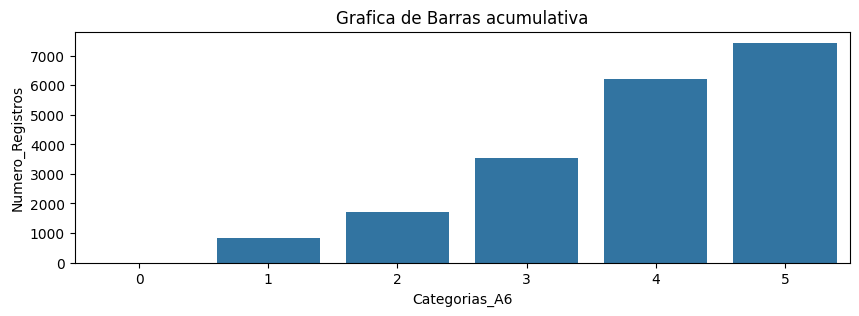

In [60]:
# Crear un lienzo con un tamano
plt.figure(figsize = (10, 3))

# Configuracion de la grafica de Barras que cuenta el numero de registros
sns.countplot(data = tabla, x = 'A6')

# Configuramos los elementos de la grafica
plt.title('Grafica de Barras acumulativa')
plt.xlabel('Categorias_A6')
plt.ylabel('Numero_Registros')

# Mostramos la grafica
plt.show()

Es la evidente que hay crecimiento exponencial de los registros clasificados de esta forma....

# **Parte #4**

Anteriormente, no analizamos los valores nulos ya que no se notaba a simple vista. Para determinar la falta de valores; lo haremos por medio de un graficacion de valores...

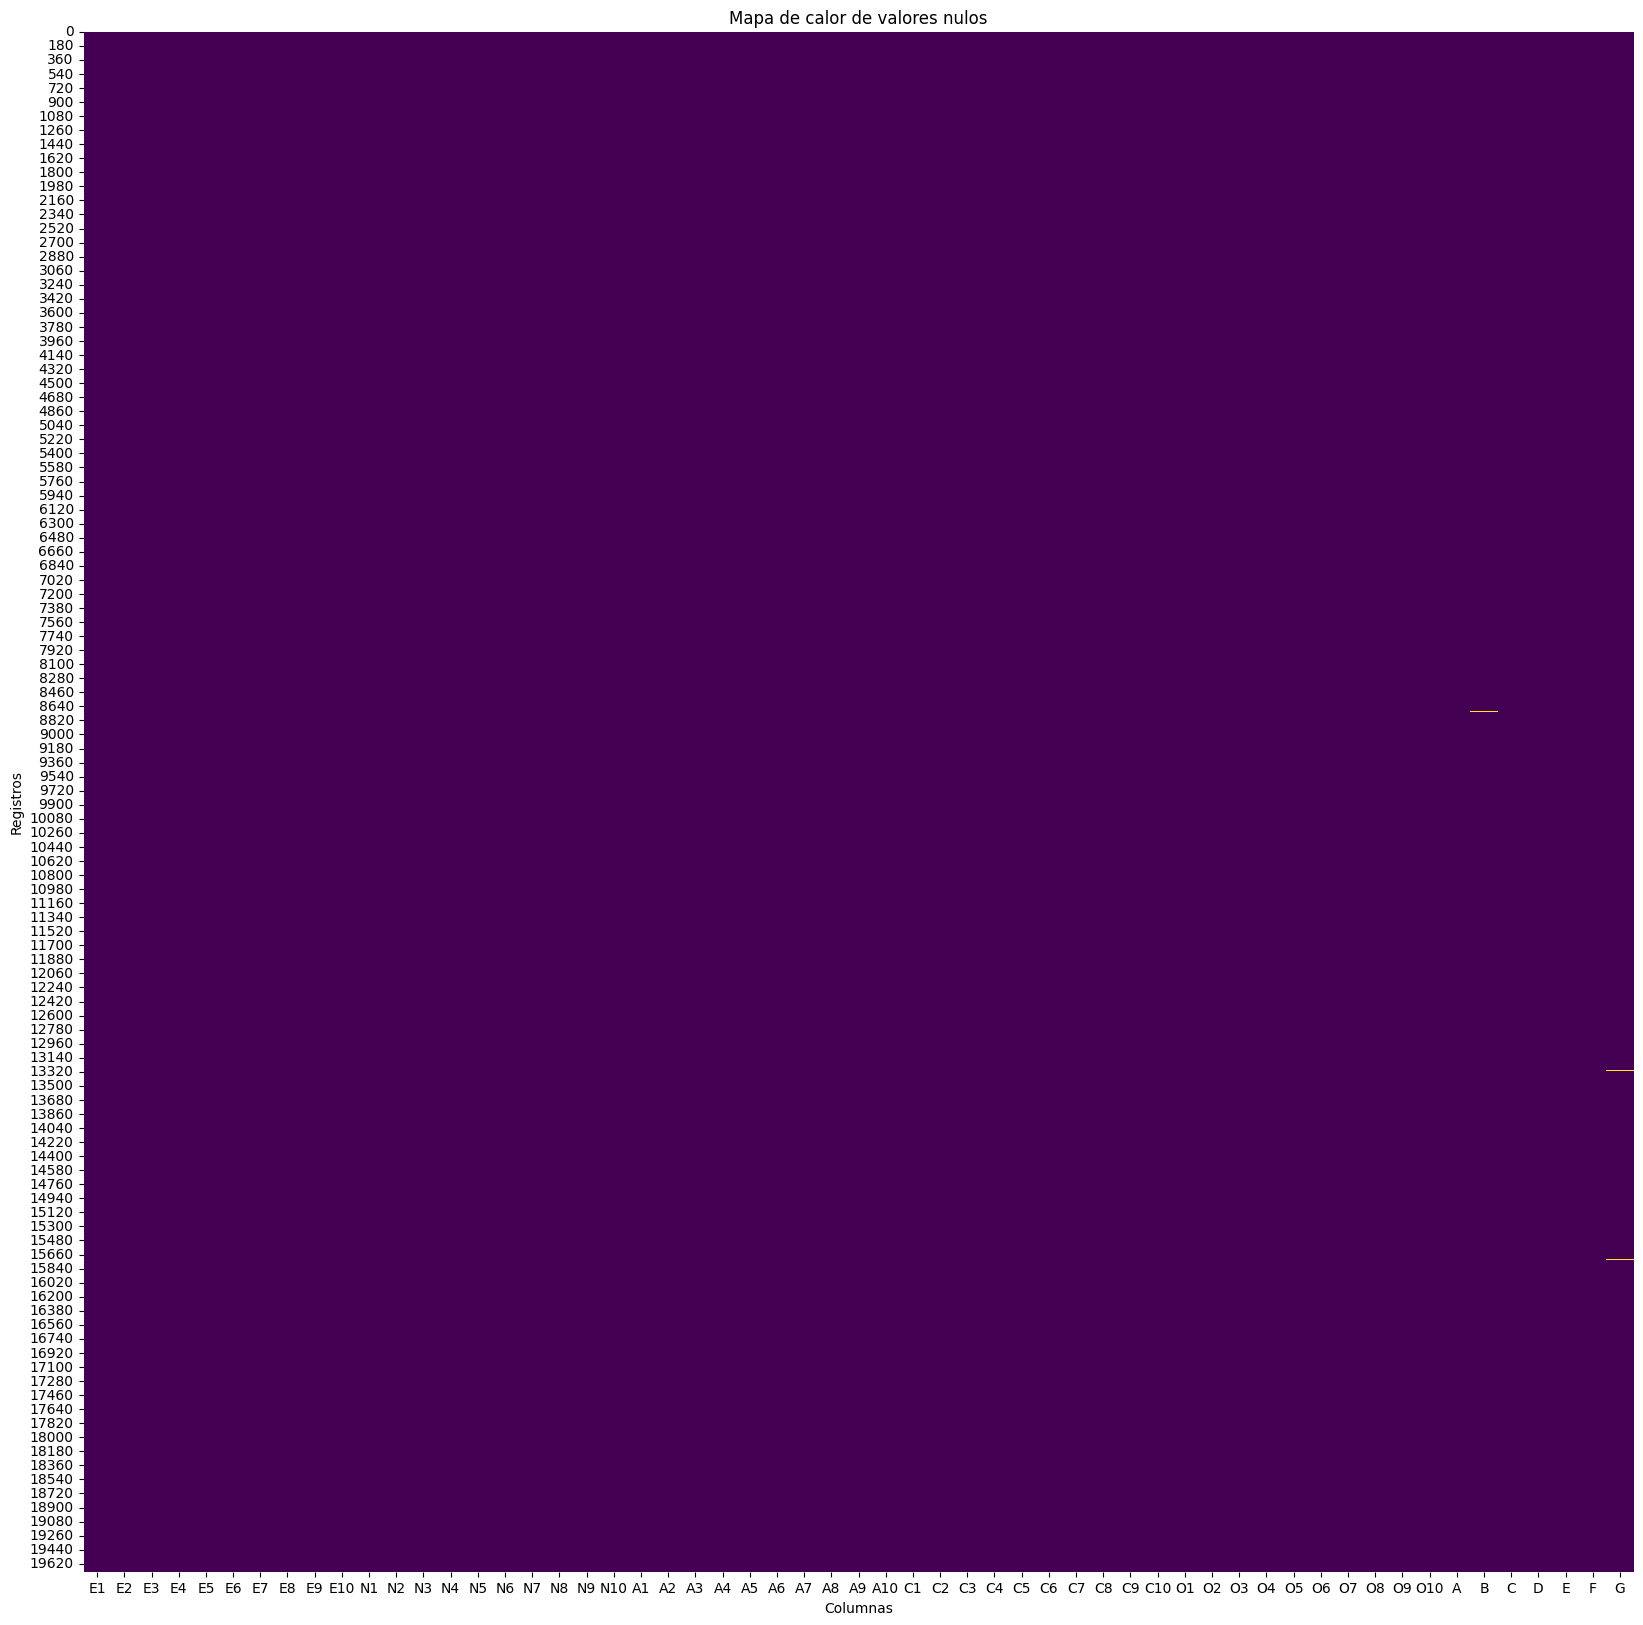

In [61]:
# Establecemos el tamano de la grafica
plt.figure(figsize=(20, 20))

# Indicamos los parametros para la grafica
sns.heatmap(tabla.isnull(), cbar=False, cmap='viridis')

# Configuramos los elementos de la grafica
plt.title('Mapa de calor de valores nulos')
plt.xlabel('Columnas')
plt.ylabel('Registros')

# Mostramos la grafica
plt.show()

Podemos ver en la grafica algunas lugares en blanco. Lo cual indica que existe valores nulos que la informacion que nos proporcionaron, en las columnas: **B**, **C** y **G**. Y lo podemos ver en la siguiente tabla y el total de datos que tiene esta condicion...

In [62]:
# Contar valores nulos por columna
nulos = pd.DataFrame(tabla.isnull().sum())

# Cambiamos el nombre de la columna
nulos.columns = ['Nulls']

nulos.tail(8)

,Nulls
O10,0
A,0
B,1
C,1
D,0
E,0
F,0
G,12


In [63]:
print("Hay un total de", nulos.sum(), "valores nulos en la tabla")

Hay un total de Nulls    14
dtype: int64 valores nulos en la tabla


# **Parte #5**

**Los datos atipicos** son aquellos que divergen en las caracteristicas generales de los valores que tiene un conjunto de datos, tales como:

* el tipo de dato.
* incongruencia en los datos.
* rango de valores.

Comunmente son descartados de los analisis siempre y cuando tiene poca proporcion de registro con el resto; pero el detalle recai en el contexto de la informacion de la base de datos *(los cuales no tenemos a disposicon)*.

Por ejemplo; el analisis anterior podemos notar su presencia en algunas V.A. la cuales son:
**D**, **E**, **F** y **A**. Una forma de determinar si son o no valores atipicos; podemos verlo por medio de 2 graficas...

## $\color{Blue}{\text{Grafica de Dispersion}}$

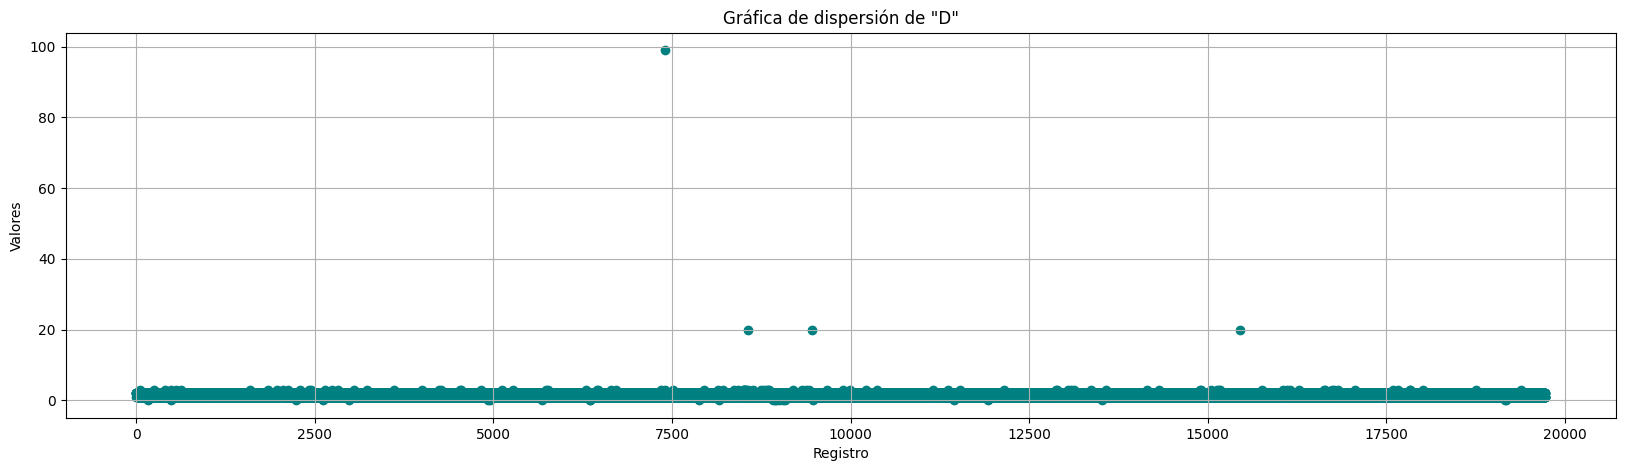

In [64]:
# Establecemos el tamano de la grafica
plt.figure(figsize = (20, 5))

# Indicamos los ejes
y = tabla['D']
x = tabla.index

# Codificamos la grafica de dispersion para la columna "D"
plt.scatter(x, y, color = 'teal')

# Configuramos loa elemento de la grafica
plt.title('Gráfica de dispersión de "D"')
plt.xlabel('Registro')
plt.ylabel('Valores')
plt.grid(True)
plt.show()

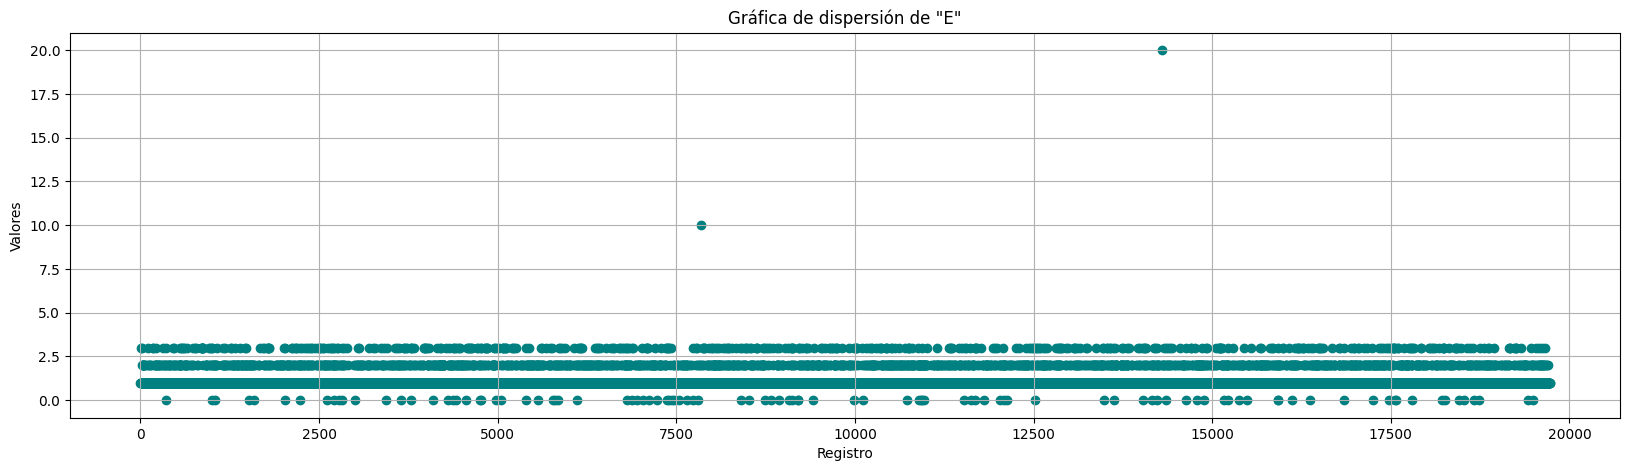

In [65]:
# Establecemos el tamano de la grafica
plt.figure(figsize = (20, 5))

# Indicamos los ejes
y = tabla['E']
x = tabla.index

# Codificamos la grafica de dispersion para la columna "E"
plt.scatter(x, y, color = 'teal')

# Configuramos loa elemento de la grafica
plt.title('Gráfica de dispersión de "E"')
plt.xlabel('Registro')
plt.ylabel('Valores')
plt.grid(True)
plt.show()

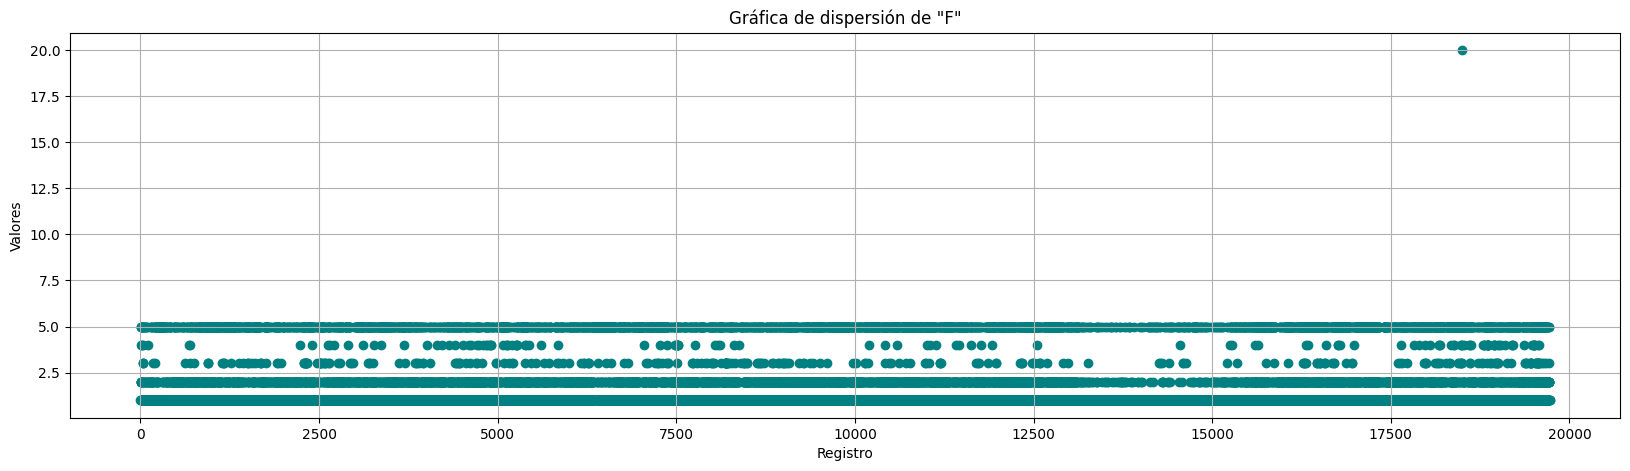

In [66]:
# Establecemos el tamano de la grafica
plt.figure(figsize = (20, 5))

# Indicamos los ejes
y = tabla['F']
x = tabla.index

# Codificamos la grafica de dispersion para la columna "F"
plt.scatter(x, y, color = 'teal')

# Configuramos loa elemento de la grafica
plt.title('Gráfica de dispersión de "F"')
plt.xlabel('Registro')
plt.ylabel('Valores')
plt.grid(True)
plt.show()

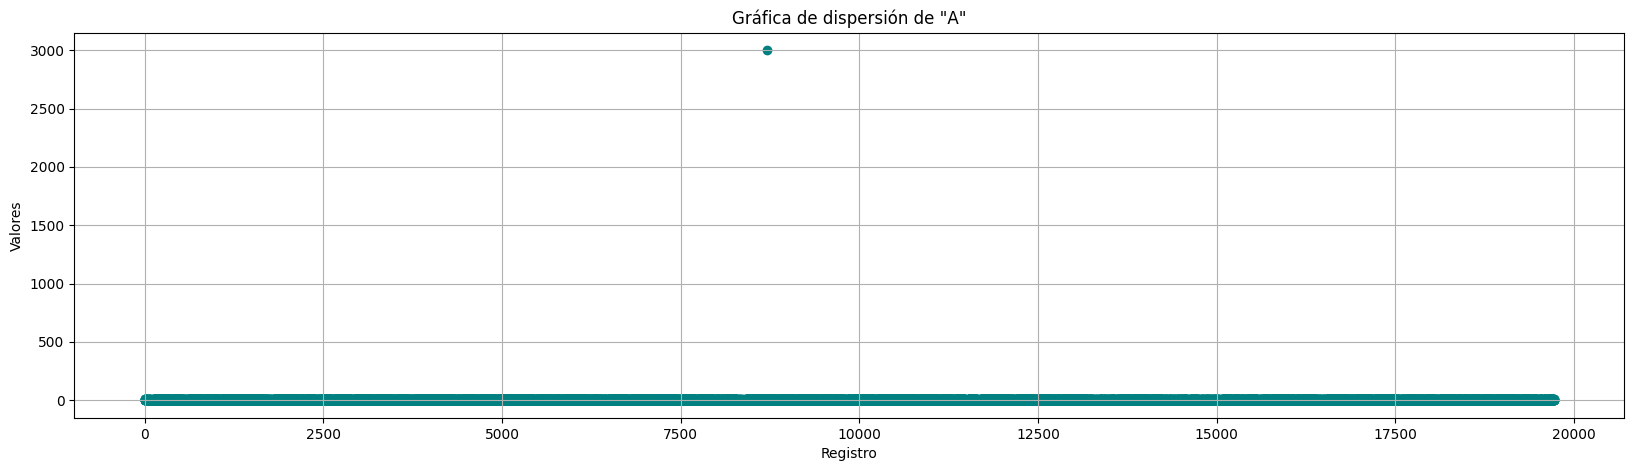

In [67]:
# Establecemos el tamano de la grafica
plt.figure(figsize = (20, 5))

# Indicamos los ejes
y = tabla['A']
x = tabla.index

# Codificamos la grafica de dispersion para la columna "A"
plt.scatter(x, y, color = 'teal')

# Configuramos loa elemento de la grafica
plt.title('Gráfica de dispersión de "A"')
plt.xlabel('Registro')
plt.ylabel('Valores')
plt.grid(True)
plt.show()

## $\color{Blue}{\text{Grafica BOX}}$

Este tipo de grafica es una visualizacion desde arriba de la distribucion Normal de un conjunto de datos dividos por sus cuartiles y por los valores atipicos seran aqeullos valores que este fuera de dicha caja....

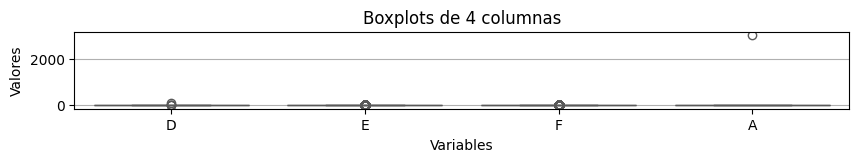

In [68]:
# Selecciona las 4 columnas que quieres graficar
columnas = ['D', 'E', 'F', 'A']

# Crear el boxplot
plt.figure(figsize = (10, 1))
sns.boxplot(data = tabla[columnas], palette ='Set2')

# Títulos y etiquetas
plt.title('Boxplots de 4 columnas')
plt.xlabel('Variables')
plt.ylabel('Valores')
plt.grid(axis='y')
plt.show()


Es claro que los datos atipos estan interviniendo con el desarrollo de esta grafica, ya que los puntos que se marcan esta fuera de esa caja. Veamos cuantos registro que tiene estos datos...

In [69]:
# Seleccionamo solo las columnas numéricas
datos = tabla.select_dtypes(include='number')

# Calcular cuartiles e IQR
Q1 = datos.quantile(0.25)
Q3 = datos.quantile(0.75)
IQR = Q3 - Q1

# Detectar los registros
registros = (datos < (Q1 - 1.5 * IQR)) | (datos > (Q3 + 1.5 * IQR))

# Contar registros con al menos un valor atípico
contar = registros.any(axis=1).sum()

# Proporcion de los datos
Registros_Totales = len(datos)
Proporcion = (contar / Registros_Totales) * 100

print(f"Registros con al menos un dato atípico: {contar}; lo que esta representando el {Proporcion.round(4)}%")

Registros con al menos un dato atípico: 11771; lo que esta representando el 59.6816%


# **Parte #6**

Para esta parte, crea que lo mas conveniente es la transformacion de los valores nulos *(no podemos eliminar los valores atipicos ya que representa el 50% de los datos y si lo hacemos estariamos obteniendo una perdida de informacion)*.

Pasando a dicha transformacion que sera algo mas sencillo de lo que parece....

In [70]:
# Para cada columna; obtenemos su moda y rellenar los nulos con dicho valor
tabla = tabla.apply(lambda col: col.fillna(col.mode()[0]))

Y para corroborrar que ya este aplicado los cambios devuelta con **la grafica de calor** anterior...

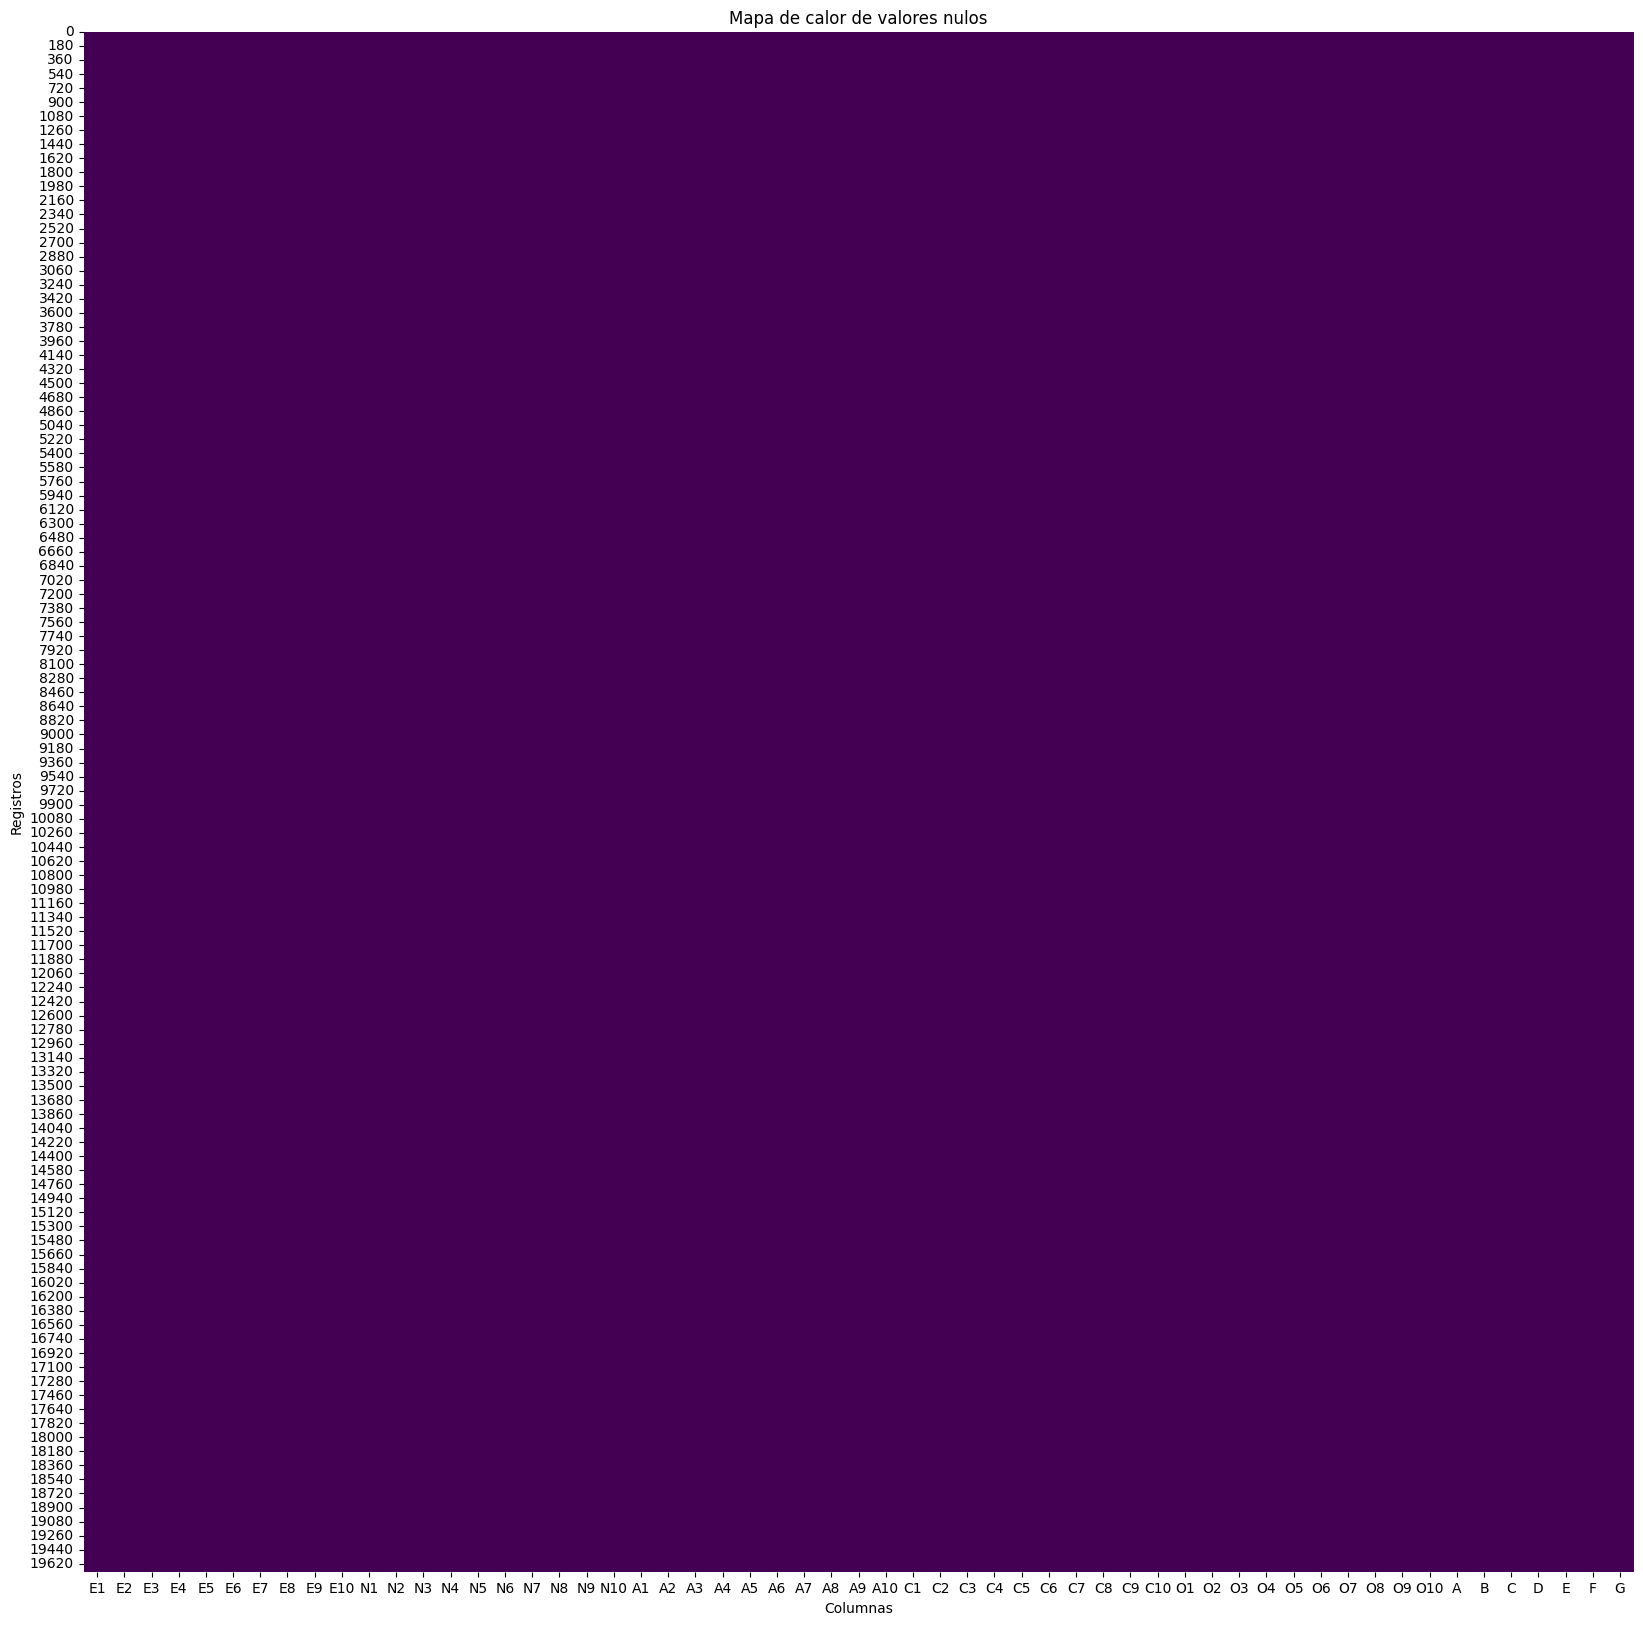

In [71]:
# Establecemos el tamano de la grafica
plt.figure(figsize=(20, 20))

# Indicamos los parametros para la grafica
sns.heatmap(tabla.isnull(), cbar=False, cmap='viridis')

# Configuramos los elementos de la grafica
plt.title('Mapa de calor de valores nulos')
plt.xlabel('Columnas')
plt.ylabel('Registros')

# Mostramos la grafica
plt.show()

Podemos ver que no hay rastros blancos en dicha grafica, por ende los cambios se han realizado...

# **Parte #7**

Por definicion tenemos que **la correlacion** es la relacion que existe entre 2 V.A., es decir; el cambio de valores de un conjunto de datos, afecta o altera el comportamiento de otro conjunto de datos de forma proporcional...

Por lo general; se utiliza 2 formulas de correlacion:

*   **Correlacion de Pearson**
*   **Correlacion de Spearman**

la diferencia entre las 2 es el hecho de que la primerra es mas eficiente a la hora de determinar la relacion entre 2 V.A. continua y la otra es eficiente sin importar el tipo de V.A. sea *(o como se comporte)*...

Veremos ambos casos ya que la variancion entre estos terminos no es demasiada. La forma en com interpretamos estos valores es la direccion que tome este termino $ \phi $ que vive entre $[-1,1]$

*   Si $ \phi > 0 $ hay una relacion proporcional de crecimiento entre ambas V.A.
*   Si $ \phi < 0 $ hay una relacion proporcional decreciente entre ambas V.A., es decir: si A crece, B decrece.
*   Si $ \phi = 0 $ No tiene relacion alguna o falta mas informacion para determinar este hecho.

Tomando las columnas representativas que seleccionamos en **la parte 2**, anadiendo a la variable: **A** para acompletar las 8 V.A.s indicadas en el problema y cambiando la columna **G** por **C** *(cuestiones de datos numericos)*...

In [72]:
# Formamos un nueva tabla

tabla_2 = tabla[['A','C','B','E10','N10','C8','O9','A7']]
tabla_2.head(12)

,A,C,B,E10,N10,C8,O9,A7
0,3,1.0,53.0,1,1,1,5,1
1,13,1.0,46.0,5,4,1,3,2
2,1,2.0,14.0,1,5,1,5,1
3,3,2.0,19.0,5,5,4,5,3
4,11,2.0,25.0,5,4,3,5,1
5,13,1.0,31.0,5,2,3,5,3
6,5,1.0,20.0,1,2,3,3,1
7,4,2.0,23.0,3,1,1,2,1
8,5,1.0,39.0,3,3,2,4,1
9,3,1.0,18.0,5,4,2,4,3


In [73]:
# Correlacion de spearman
corSp = tabla_2.corr( method = 'spearman')
corSp

,A,C,B,E10,N10,C8,O9,A7
A,1.000000,0.268289,-0.045775,0.027721,-0.008630,0.014912,-0.091640,0.038007
C,0.268289,1.000000,0.032878,0.024954,0.063497,0.104426,-0.075117,0.095874
B,-0.045775,0.032878,1.000000,-0.165415,-0.105093,-0.263246,0.045839,-0.068922
E10,0.027721,0.024954,-0.165415,1.000000,0.250412,0.124749,0.132655,0.254275
N10,-0.008630,0.063497,-0.105093,0.250412,1.000000,0.238754,0.166707,0.173455
C8,0.014912,0.104426,-0.263246,0.124749,0.238754,1.000000,-0.024156,0.174169
O9,-0.091640,-0.075117,0.045839,0.132655,0.166707,-0.024156,1.000000,-0.075357
A7,0.038007,0.095874,-0.068922,0.254275,0.173455,0.174169,-0.075357,1.000000


In [74]:
# Correlacion de Pearson
matriz = tabla_2.corr(method='pearson')
matriz

,A,C,B,E10,N10,C8,O9,A7
A,1.000000,0.034989,-0.001140,0.007744,-0.013377,-0.001490,-0.013842,0.016832
C,0.034989,1.000000,0.009246,0.024729,0.059788,0.100338,-0.069734,0.094445
B,-0.001140,0.009246,1.000000,0.007718,0.011734,-0.009308,0.006259,-0.007300
E10,0.007744,0.024729,0.007718,1.000000,0.247833,0.126368,0.110725,0.253900
N10,-0.013377,0.059788,0.011734,0.247833,1.000000,0.239038,0.166708,0.166568
C8,-0.001490,0.100338,-0.009308,0.126368,0.239038,1.000000,-0.011803,0.167301
O9,-0.013842,-0.069734,0.006259,0.110725,0.166708,-0.011803,1.000000,-0.055669
A7,0.016832,0.094445,-0.007300,0.253900,0.166568,0.167301,-0.055669,1.000000


Una curiosidad de esta **Matrices de correlacion** es el hecho de que la diagonal principal siempre sera $1$ ya que tiene una **Correlacion Perfecta**.

Ya que se compara la misma V.A. Pero a este punto no es muy factible ver cada uno de los terminos *(es mas latoso)*, por lo que una grafica de calor es mas sencillo de detectar V.A. tiene correlacion o no....

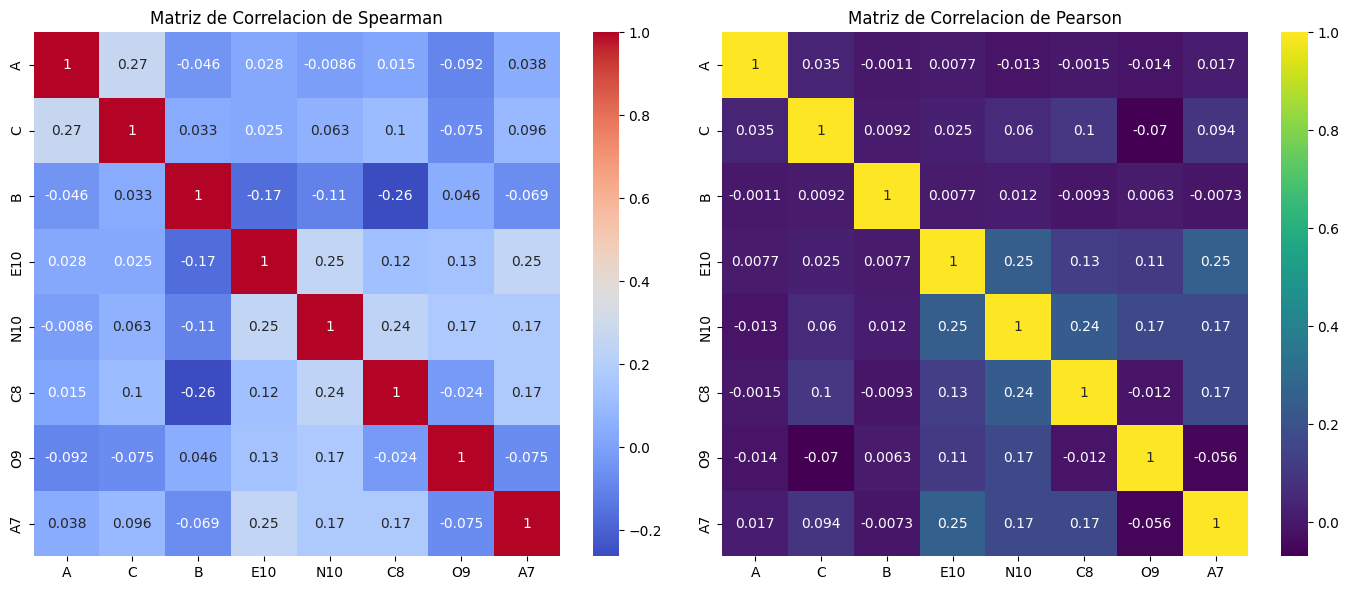

In [75]:
# Crear el lienzo con 1 fila, 2 columnas
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# Primera gráfica de calor
sns.heatmap(corSp, annot = True, cmap = 'coolwarm', ax = axes[0])
axes[0].set_title('Matriz de Correlacion de Spearman')

# Segunda gráfica de calor
sns.heatmap(matriz, annot = True, cmap = 'viridis', ax = axes[1])
axes[1].set_title('Matriz de Correlacion de Pearson')

plt.tight_layout()
plt.show()

Podemos sacar algunas conclusiones que podemos sacar de ambas matrices es:

*   Hecho de la mayoria de las relaciones de aproxima a cero *(indicativo de casi nula relacion)*

*   La correlacion positiva mas grande es: $ \phi = .25,.26 $

*   La correlacion negativa mas pequena es: $ \phi = -.26 $ o $ \phi = -.07 $ *(para el caso de Pearson)*